In [1]:
import numpy as np
import torch
import scanpy as sc
import anndata as ad
import os
import pandas as pd
from utils.preprocess import *

In [2]:
import os
import sys
    
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import torch
import torchsde
from torchdyn.core import NeuralODE
from tqdm import tqdm

from torchcfm.conditional_flow_matching import *
from torchcfm.models import MLP
from torchcfm.utils import plot_trajectories, torch_wrapper
from simulate.simulate import *
from omegaconf import OmegaConf
from utils.hydra import *
from datasets.process import *
from scripts.run_model import *

In [3]:
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
%reload_ext autoreload
%autoreload 2

In [5]:
dic = {"s": sample_s,
       "s_imbalanced": sample_s_imbalanced,
       "points": sample_points,
       "diamond": sample_diamond,
       "omega": sample_omega,
       "moons": sample_moons,
       "disk": sample_disk,
       }

In [6]:
############################################################

In [7]:
### SETTINGS ###

dataname = "disk"
size = 4000
d = 2 #dummy dimension

project = "ffm-ipynb"
adata = process_fake_data(size, d, dic[dataname])
config = load_config()
OmegaConf.set_struct(config, False)
config.pc_dim = d
config.num_classes = adata.obs['cell_type'].nunique()

##################
config.metric = "mfm"
config.finsler.use = False
config.finsler.lamb = 3.0
config.flow_max_epochs = 2



In [8]:
adata

AnnData object with n_obs × n_vars = 4000 × 2
    obs: 'timepoint', 'gene_target', 'cell_type', 'cell_type_one_hot'
    uns: 'std', 'tree'
    obsm: 'X_pca'
    varm: 'PCs'

In [9]:
############################################################

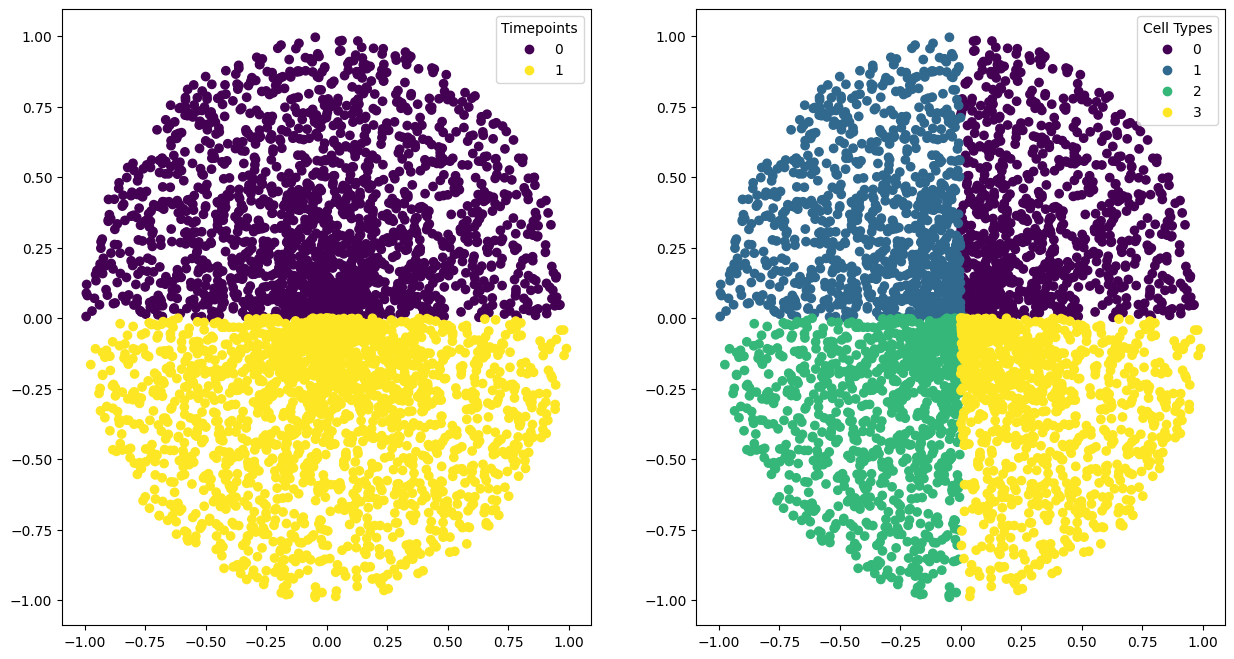

In [10]:
samples = torch.from_numpy(adata.obsm['X_pca']).float()
fig, axs = plt.subplots(1, 2, figsize = (15, 8))
scatter0 = axs[0].scatter(samples[:,0], samples[:, 1], c=adata.obs['timepoint'].astype(int).tolist())
handles, labels = scatter0.legend_elements()
axs[0].legend(handles, labels, title="Timepoints")
scatter1 = axs[1].scatter(samples[:,0], samples[:, 1], c=adata.obs['cell_type_one_hot'].astype(int).tolist())
handles, labels = scatter1.legend_elements()
axs[1].legend(handles, labels, title="Cell Types")

plt.show()

In [11]:
tree = adata.uns['tree']
timepoints = sorted(adata.obs['timepoint'].unique().tolist())
singleton_dataloader = build_singleton_dataloader(config, adata)
paired_dataloader = build_paired_dataloader(config, adata)
classifier_model, metric_model, embed_model, flow_model = run_full_model(config=config,
                                                                         project=project,
                                                                         singleton_dataloader=singleton_dataloader,
                                                                         paired_dataloader=paired_dataloader,
                                                                         timepoints=timepoints,
                                                                         tree=tree)

### DEBUG: classifier is constrained to linear ###
DEBUG: turned off random v in embed loss
Running phase classifier:.......


wandb: Currently logged in as: az831 (az831-new-york-genome-center) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/azweig/miniconda3/envs/spatialenv/lib/python3.10/site-packages/pytorch_lightning/loggers/wandb.py:397: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.
wandb: logging graph, to disable use `wandb.watch(log_graph=False)`
You are using a CUDA device ('NVIDIA GeForce RTX 4080 SUPER') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name           | Type           | Params | Mode 
----------------------------------------------------

epoch,▁▁▁▁▂▂▂▂▂▂▂▂▃▃▃▃▃▃▃▃▄▄▄▄▅▅▅▅▅▅▅▆▆▇▇▇▇███
train_ce,█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_kl,▁██▅▄▃▃▂▂▂▂▂▂▂▂▃▃▃▂▂▃▂▂▂▃▃▂▂▃▃▂▂▂▂▂▂▂▂▂▂
train_loss,▆▆▆█▄▄▂▅▆▃▃▂▅▃▃▃▄▄▂▆▂▁▄▅▄▅▁▂▅▃▄▁▄▃▂▂▂▂▁▂
trainer/global_step,▁▁▁▁▁▁▂▂▂▂▂▂▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇██
epoch,499
train_ce,0.18159
train_kl,2.80275
train_loss,0.32173
trainer/global_step,499


Running phase metric:.......


...

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/azweig/miniconda3/envs/spatialenv/lib/python3.10/site-packages/pytorch_lightning/loggers/wandb.py:397: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.
wandb: logging graph, to disable use `wandb.watch(log_graph=False)`
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name         | Type           | Params | Mode 
--------------------------------------------------------
0 | embed_net    | SimpleEmbedNet | 225 K  | train
1 | geo_net      | SinNet         | 217 K  | train
2 | metric_model | MetricNetMFM   | 500    | eval 
--------------------------------------------------------
443 K     Trainable params
500       Non-trainable params
443 K     Total params
1.776     Total estimated model params size (MB)
32        Modules in train 

epoch,▁▁▁▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇████
train_loss_embed,▄▆▆▃▆▅█▄▅▅▄▂▇▃▄▄▅▄▃▅▅▅▄▄▂▂▃▄▅▅█▆▁▃▇▃▇▄▃▃
train_loss_geo,▃▅▃▂▃▆▃▃▆▇▅▆▃▄▂▁▂▅▃▃▅▁▂▅▂▃▅▆▃▂▄▅█▅▅▅▅▄▂▃
trainer/global_step,▁▁▁▁▁▂▂▂▂▂▂▂▂▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▅▅▆▆▆▇▇▇▇▇██
epoch,2999
train_loss_embed,0.41371
train_loss_geo,1.03982
trainer/global_step,2999


Running phase flow:.......


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/azweig/miniconda3/envs/spatialenv/lib/python3.10/site-packages/pytorch_lightning/loggers/wandb.py:397: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.
wandb: logging graph, to disable use `wandb.watch(log_graph=False)`
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name        | Type              | Params | Mode 
----------------------------------------------------------
0 | flow_net    | SinNet            | 217 K  | train
1 | embed_model | EmbedNetTrainBase | 443 K  | eval 
----------------------------------------------------------
217 K     Trainable params
443 K     Non-trainable params
661 K     Total params
2.644     Total estimated model params size (MB)
16        Modules in train mode
34        Modules in eval mode
/home

epoch,▁█
train_loss,▁█
trainer/global_step,▁█
epoch,1
train_loss,15.18137
trainer/global_step,1


In [12]:
#fix the wandb.run.summary bug?
def remove_all_forward_hooks(model):
    for module in model.modules():
        module._forward_hooks.clear()

remove_all_forward_hooks(classifier_model)
remove_all_forward_hooks(metric_model)
remove_all_forward_hooks(embed_model)
remove_all_forward_hooks(flow_model)

In [13]:
if config.finsler.use:

    X = torch.from_numpy(adata.obsm['X_pca']).float()
    y = torch.from_numpy(adata.obs['cell_type_one_hot'].astype(int).to_numpy()).long()
    y_pred = classifier_model(X).argmax(dim=1)

    fig, axs = plt.subplots(3, figsize = (8,15))
    axs[0].scatter(X[:,0], X[:, 1], c=y)
    axs[1].scatter(X[:,0], X[:, 1], c=y_pred)
    
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    h = 0.02  # Step size for the mesh
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    grid_points = np.c_[xx.ravel(), yy.ravel()]
    grid_tensor = torch.FloatTensor(grid_points)

    with torch.no_grad():
        logits = classifier_model(grid_tensor)
        predictions = torch.argmax(logits, dim=1)

    Z = predictions.cpu().numpy().reshape(xx.shape)
    
    axs[2].contourf(xx, yy, Z, alpha=0.3, cmap='viridis')    
    scatter = axs[2].scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolors='k', s=50)

    plt.show()
    

In [14]:
#NOTE: only works for MFM
def visualize_metric(metric_model, samples, grid_steps=30):

    import torch, numpy as np, matplotlib.pyplot as plt
    from scipy.stats import gaussian_kde
    plt.close('all')

    m = torch.max(torch.abs(samples)).item() + 1.0
    xs = torch.linspace(-m,  m, steps=grid_steps)
    ys = torch.linspace(-m,  m, steps=grid_steps)
    xg, yg = torch.meshgrid(xs, ys, indexing='xy')
    z   = torch.stack([xg, yg], dim=-1).reshape(-1, 2)

    zeros = torch.zeros(z.shape[0], d-2, device=z.device, dtype=z.dtype)
    z = torch.cat([z, zeros], dim=1) 

    print(z.shape)
    print(metric_model.M(z.to('cuda')).detach().shape)

    E = metric_model.M(z.to('cuda')).detach().reshape(grid_steps, grid_steps).cpu()

    fig, ax = plt.subplots()

    contour = ax.contourf(xg, yg, -E, levels=100, cmap='inferno')
    ax.scatter(samples[:, 0], samples[:, 1], s=2, alpha=0.005)
    ax.set_aspect('equal')
    fig.colorbar(contour, ax=ax, label="negative metric tensor")
    plt.show()

torch.Size([900, 2])
torch.Size([900])


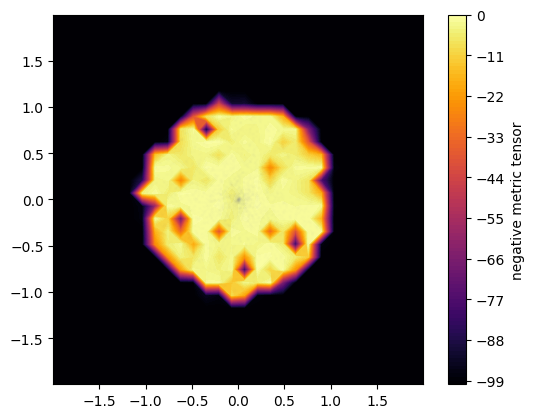

In [15]:
if config.metric == "mfm":
    samples = torch.from_numpy(adata.obsm['X_pca']).float()
    visualize_metric(metric_model, samples)

In [16]:
from torch.utils.data import TensorDataset, Sampler, DataLoader
from datasets.dataset import *

dataset = extract_paired_dataset(adata)
train_dataset = ShufflingDataset(dataset, 20)
train_dataloader = DataLoader(train_dataset, batch_size = config.loader_batch_size, shuffle=True)

In [17]:
# #EMBED VALIDATION

# for batch in train_dataloader:
    
#     x0, x1, t0, t1 = embed_model._prepare_batch(batch)
#     t0 = embed_model.normalize_time(t0)
#     t1 = embed_model.normalize_time(t1)
    
#     x0_, x1_ = x0[0], x1[0]
#     x0, x1 = embed_model.flow_matcher.ot_sample(x0_, x1_)

#     break

# from matplotlib.collections import LineCollection

# src_np = x0.detach().cpu().numpy()
# tgt_np = x1.detach().cpu().numpy()

# N = src_np.shape[0]

# max_lines = 100
# if N > max_lines:
#     indices = np.random.choice(N, max_lines, replace=False)
# else:
#     indices = np.arange(N)

# segments = np.stack((src_np[indices], tgt_np[indices]), axis=1)

# fig, ax = plt.subplots(figsize=(8, 8))
# lc = LineCollection(segments, colors='gray', alpha=0.3, linewidths=0.8, zorder=1)
# ax.add_collection(lc)
# samples = torch.from_numpy(adata.obsm['X_pca']).float()
# ax.scatter(samples[:,0], samples[:, 1], c=adata.obs['timepoint'].astype(int).tolist())
# ax.scatter(src_np[:, 0], src_np[:, 1], c='blue', alpha=0.6, s=20, label='Source', zorder=2)
# ax.scatter(tgt_np[:, 0], tgt_np[:, 1], c='red', alpha=0.6, s=20, label='Target', zorder=2)

# ax.legend()
# ax.grid(True, linestyle='--', alpha=0.3)

# ax.autoscale()
# plt.show()

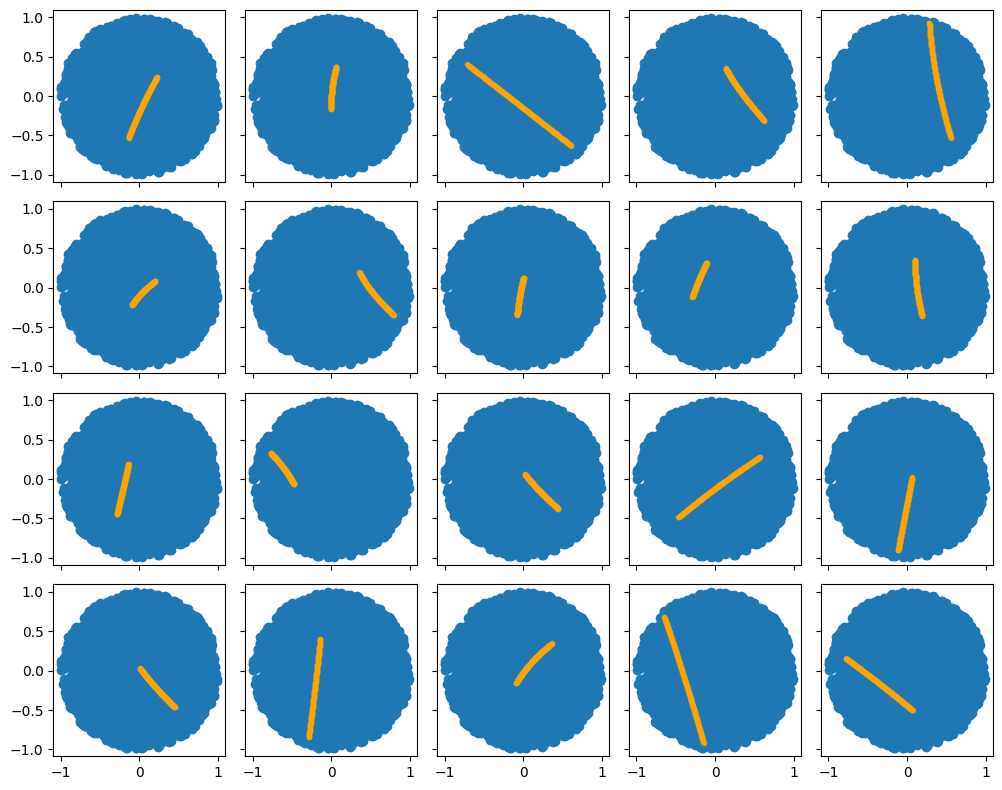

In [18]:
#GEO VALIDATION
for batch in train_dataloader:
    
    paths = embed_model.sample_geodesic(batch, points=200, ot_sample=False)

    break

fig, ax = plt.subplots(4, 5, figsize=(10, 8), sharex=True, sharey=True)

ax = ax.flatten()

for i in range(20):
    traj = paths[:,i]
    ax[i].scatter(samples[:,0], samples[:, 1])
    ax[i].plot(traj[:, 0], traj[:, 1], marker=".", linestyle="-", alpha=0.7, lw=1.5, color='orange')
    ax[i].set(adjustable='box', aspect='equal')

plt.tight_layout() # Optional: adjusts spacing so labels don't overlap
plt.show()

In [19]:
#EMBED VALIDATION
if config.metric == "cfm" and not config.finsler.use:
    x0, x1, _, _= embed_model._prepare_batch(batch)
    x0, x1 = x0[0], x1[0]
    true_dist = torch.norm(x0 - x1, dim = -1)
    f = embed_model.embed_fn
    learned_dist = torch.norm(f(x0).detach() - f(x1).detach(), dim=-1)
    print(torch.stack([true_dist, learned_dist], dim=1)[:10])

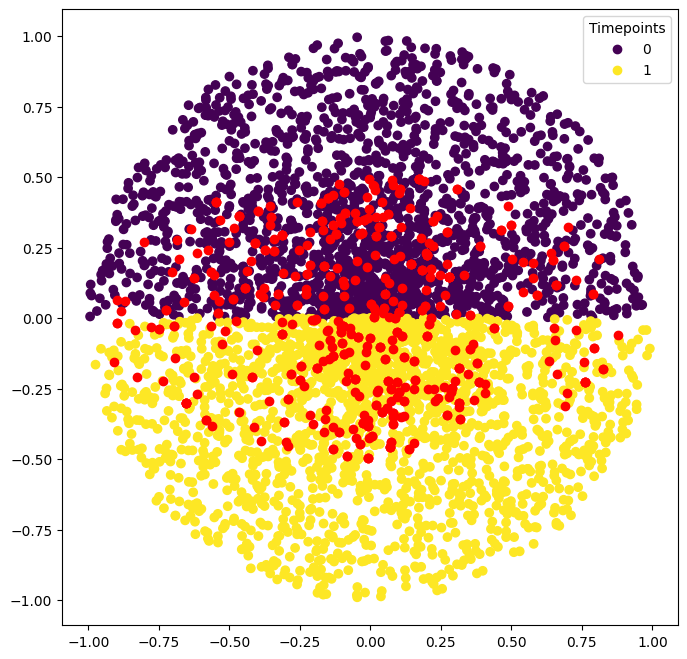

In [20]:
#GEO INTERPOLATION VALIDATION

t0 = 0
t = t0 + 0.5
t1 = t0 + 1

adata_prune = adata[adata.obs['timepoint'].isin([t0, t1])]
dataset = extract_paired_dataset(adata_prune)
train_dataset = ShufflingDataset(dataset, 512)
train_dataloader = DataLoader(train_dataset, batch_size = 1)

batch = next(iter(train_dataloader))
interp_samples = embed_model.sample_geodesic_time(batch, t)

samples = torch.from_numpy(adata.obsm['X_pca']).float()
fig, axs = plt.subplots(1, figsize = (15, 8))
scatter0 = axs.scatter(samples[:,0], samples[:, 1], c=adata.obs['timepoint'].astype(int).tolist())
handles, labels = scatter0.legend_elements()
axs.legend(handles, labels, title="Timepoints")
axs.scatter(interp_samples[:,0], interp_samples[:,1], c="red")
axs.set_aspect('equal')

plt.show()

In [21]:
#FLOW VALIDATION

num_samples = 500
steps = 500

In [22]:
from datasets.dataset import sample
def plot_flow(t0):
    t1 = t0 + 1
    x = adata[adata.obs['timepoint'].astype(int) == t0].obsm['X_pca']
    x = sample(x, min(num_samples, x.shape[0]))
    x = torch.from_numpy(x).float()
    traj = flow_model.sample_traj(x, t0, t1, num_samples, steps=steps)
    plot_trajectories(traj.cpu().numpy())

In [23]:
# x = [[-1, 0]]
# v = [[0, -1]]

# x = torch.tensor(x).float()
# v = torch.tensor(v).float()

# # metric_model(x, v)

# f_x, Jf_x_v = jvp(metric_model.classifier_fn, (x,), (v,))

# u = 1 - f_x @ (metric_model.tree.to(metric_model.get_device()) + torch.eye(f_x.shape[-1], device=x.device))

# # D = self.fisher_rao(x)
# D = torch.ones_like(f_x)

# finsler_term = torch.sum(Jf_x_v * D * u, dim=-1)
# finsler_term = F.relu(finsler_term)
# print(f_x)
# print(Jf_x_v)
# print(u)
# print(finsler_term)

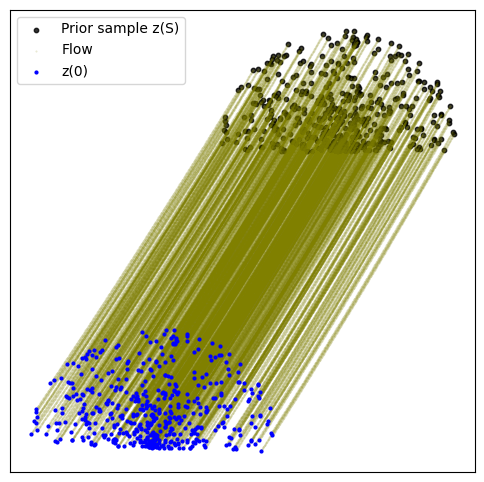

In [24]:
plot_flow(0)

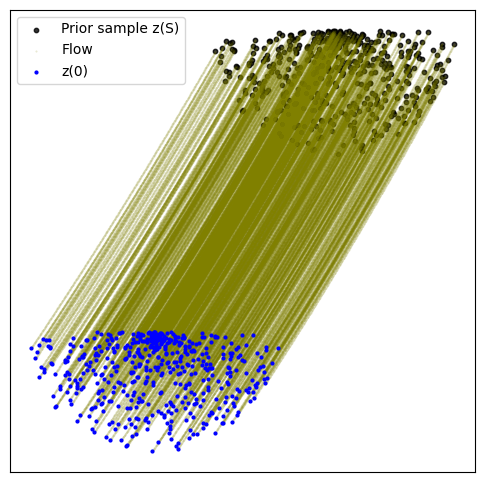

In [25]:
plot_flow(1)

In [26]:
plot_flow(2)

ValueError: a must be greater than 0 unless no samples are taken

In [ ]:
plot_flow(3)

In [ ]:
plot_flow(4)